In [45]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno


BASE_PATH = "/kaggle/input/datasets/rohanrao/formula-1-world-championship-1950-2020/"

Input : Driver
Output : Whether they will be on the podium or not (positionOrder <=3)

In [18]:
# Loading the Tables
races = pd.read_csv(f"{BASE_PATH}races.csv")
results = pd.read_csv(f"{BASE_PATH}results.csv")
circuits = pd.read_csv(f"{BASE_PATH}circuits.csv")
drivers = pd.read_csv(f"{BASE_PATH}drivers.csv")
constructors = pd.read_csv(f"{BASE_PATH}constructors.csv")
status = pd.read_csv(f"{BASE_PATH}status.csv")
qualifying = pd.read_csv(f"{BASE_PATH}qualifying.csv")


In [19]:
races.head()

,raceId,year,round,circuitId,name,date,time,url,fp1_date,fp1_time,fp2_date,fp2_time,fp3_date,fp3_time,quali_date,quali_time,sprint_date,sprint_time
0,1,2009,1,1,Australian Grand Prix,2009-03-29,06:00:00,http://en.wikipedia.org/wiki/2009_Australian_G...,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N
1,2,2009,2,2,Malaysian Grand Prix,2009-04-05,09:00:00,http://en.wikipedia.org/wiki/2009_Malaysian_Gr...,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N
2,3,2009,3,17,Chinese Grand Prix,2009-04-19,07:00:00,http://en.wikipedia.org/wiki/2009_Chinese_Gran...,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N
3,4,2009,4,3,Bahrain Grand Prix,2009-04-26,12:00:00,http://en.wikipedia.org/wiki/2009_Bahrain_Gran...,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N
4,5,2009,5,4,Spanish Grand Prix,2009-05-10,12:00:00,http://en.wikipedia.org/wiki/2009_Spanish_Gran...,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N


In [20]:
results.head()

,resultId,raceId,driverId,constructorId,number,grid,position,positionText,positionOrder,points,laps,time,milliseconds,fastestLap,rank,fastestLapTime,fastestLapSpeed,statusId
0,1,18,1,1,22,1,1,1,1,10.0,58,1:34:50.616,5690616,39,2,1:27.452,218.300,1
1,2,18,2,2,3,5,2,2,2,8.0,58,+5.478,5696094,41,3,1:27.739,217.586,1
2,3,18,3,3,7,7,3,3,3,6.0,58,+8.163,5698779,41,5,1:28.090,216.719,1
3,4,18,4,4,5,11,4,4,4,5.0,58,+17.181,5707797,58,7,1:28.603,215.464,1
4,5,18,5,1,23,3,5,5,5,4.0,58,+18.014,5708630,43,1,1:27.418,218.385,1


In [21]:
circuits.head()

,circuitId,circuitRef,name,location,country,lat,lng,alt,url
0,1,albert_park,Albert Park Grand Prix Circuit,Melbourne,Australia,-37.84970,144.96800,10,http://en.wikipedia.org/wiki/Melbourne_Grand_P...
1,2,sepang,Sepang International Circuit,Kuala Lumpur,Malaysia,2.76083,101.73800,18,http://en.wikipedia.org/wiki/Sepang_Internatio...
2,3,bahrain,Bahrain International Circuit,Sakhir,Bahrain,26.03250,50.51060,7,http://en.wikipedia.org/wiki/Bahrain_Internati...
3,4,catalunya,Circuit de Barcelona-Catalunya,Montmeló,Spain,41.57000,2.26111,109,http://en.wikipedia.org/wiki/Circuit_de_Barcel...
4,5,istanbul,Istanbul Park,Istanbul,Turkey,40.95170,29.40500,130,http://en.wikipedia.org/wiki/Istanbul_Park


In [22]:
drivers.head()

,driverId,driverRef,number,code,forename,surname,dob,nationality,url
0,1,hamilton,44,HAM,Lewis,Hamilton,1985-01-07,British,http://en.wikipedia.org/wiki/Lewis_Hamilton
1,2,heidfeld,\N,HEI,Nick,Heidfeld,1977-05-10,German,http://en.wikipedia.org/wiki/Nick_Heidfeld
2,3,rosberg,6,ROS,Nico,Rosberg,1985-06-27,German,http://en.wikipedia.org/wiki/Nico_Rosberg
3,4,alonso,14,ALO,Fernando,Alonso,1981-07-29,Spanish,http://en.wikipedia.org/wiki/Fernando_Alonso
4,5,kovalainen,\N,KOV,Heikki,Kovalainen,1981-10-19,Finnish,http://en.wikipedia.org/wiki/Heikki_Kovalainen


In [23]:
constructors.head()

,constructorId,constructorRef,name,nationality,url
0,1,mclaren,McLaren,British,http://en.wikipedia.org/wiki/McLaren
1,2,bmw_sauber,BMW Sauber,German,http://en.wikipedia.org/wiki/BMW_Sauber
2,3,williams,Williams,British,http://en.wikipedia.org/wiki/Williams_Grand_Pr...
3,4,renault,Renault,French,http://en.wikipedia.org/wiki/Renault_in_Formul...
4,5,toro_rosso,Toro Rosso,Italian,http://en.wikipedia.org/wiki/Scuderia_Toro_Rosso


In [24]:
status.head()

,statusId,status
0,1,Finished
1,2,Disqualified
2,3,Accident
3,4,Collision
4,5,Engine


In [25]:
qualifying.head()

,qualifyId,raceId,driverId,constructorId,number,position,q1,q2,q3
0,1,18,1,1,22,1,1:26.572,1:25.187,1:26.714
1,2,18,9,2,4,2,1:26.103,1:25.315,1:26.869
2,3,18,5,1,23,3,1:25.664,1:25.452,1:27.079
3,4,18,13,6,2,4,1:25.994,1:25.691,1:27.178
4,5,18,2,2,3,5,1:25.960,1:25.518,1:27.236


In [26]:
sentinels = [
    r"\N",
    "NA", "N/A", "NULL", "None", "NaN",
    "unknown", "missing", "not available",
    "?", "-", "--"
]

races = races.replace(sentinels, np.nan)
results = results.replace(sentinels, np.nan)
circuits = circuits.replace(sentinels, np.nan)
drivers = drivers.replace(sentinels, np.nan)
constructors = constructors.replace(sentinels, np.nan)
status = status.replace(sentinels, np.nan)
qualifying = qualifying.replace(sentinels, np.nan)

<Axes: >

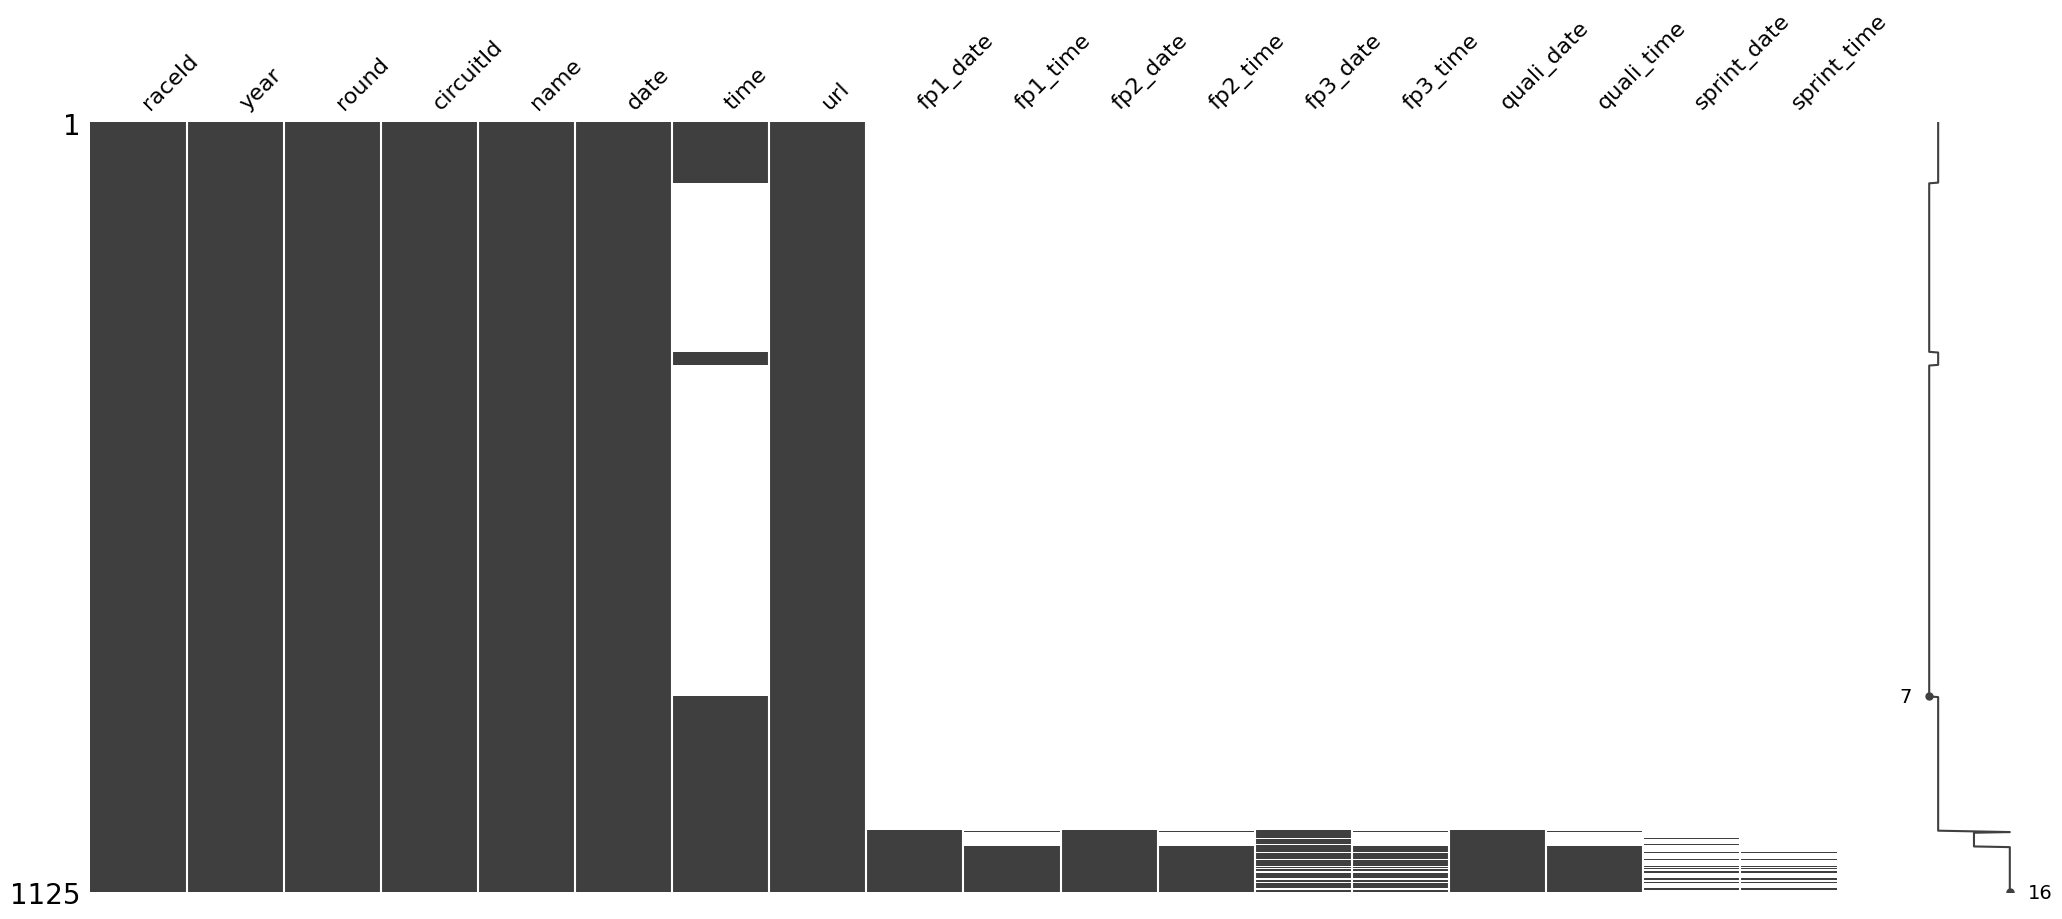

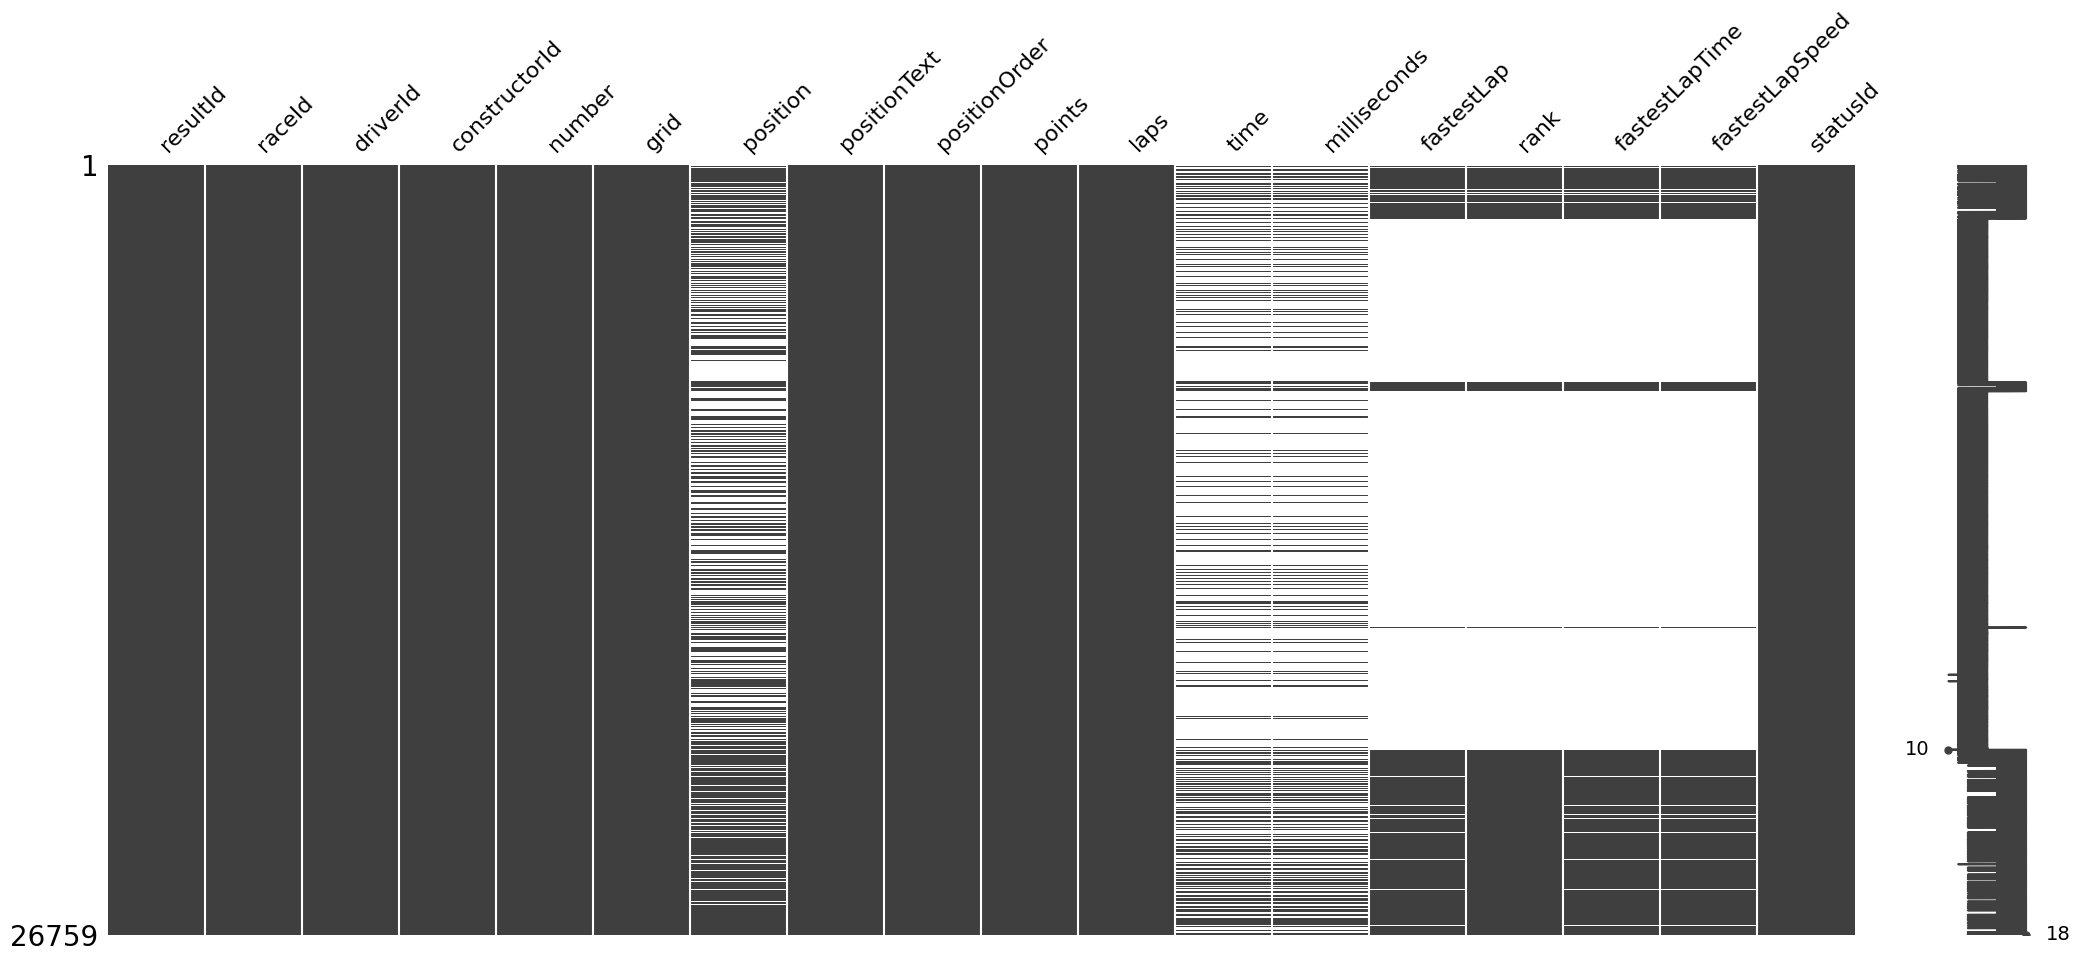

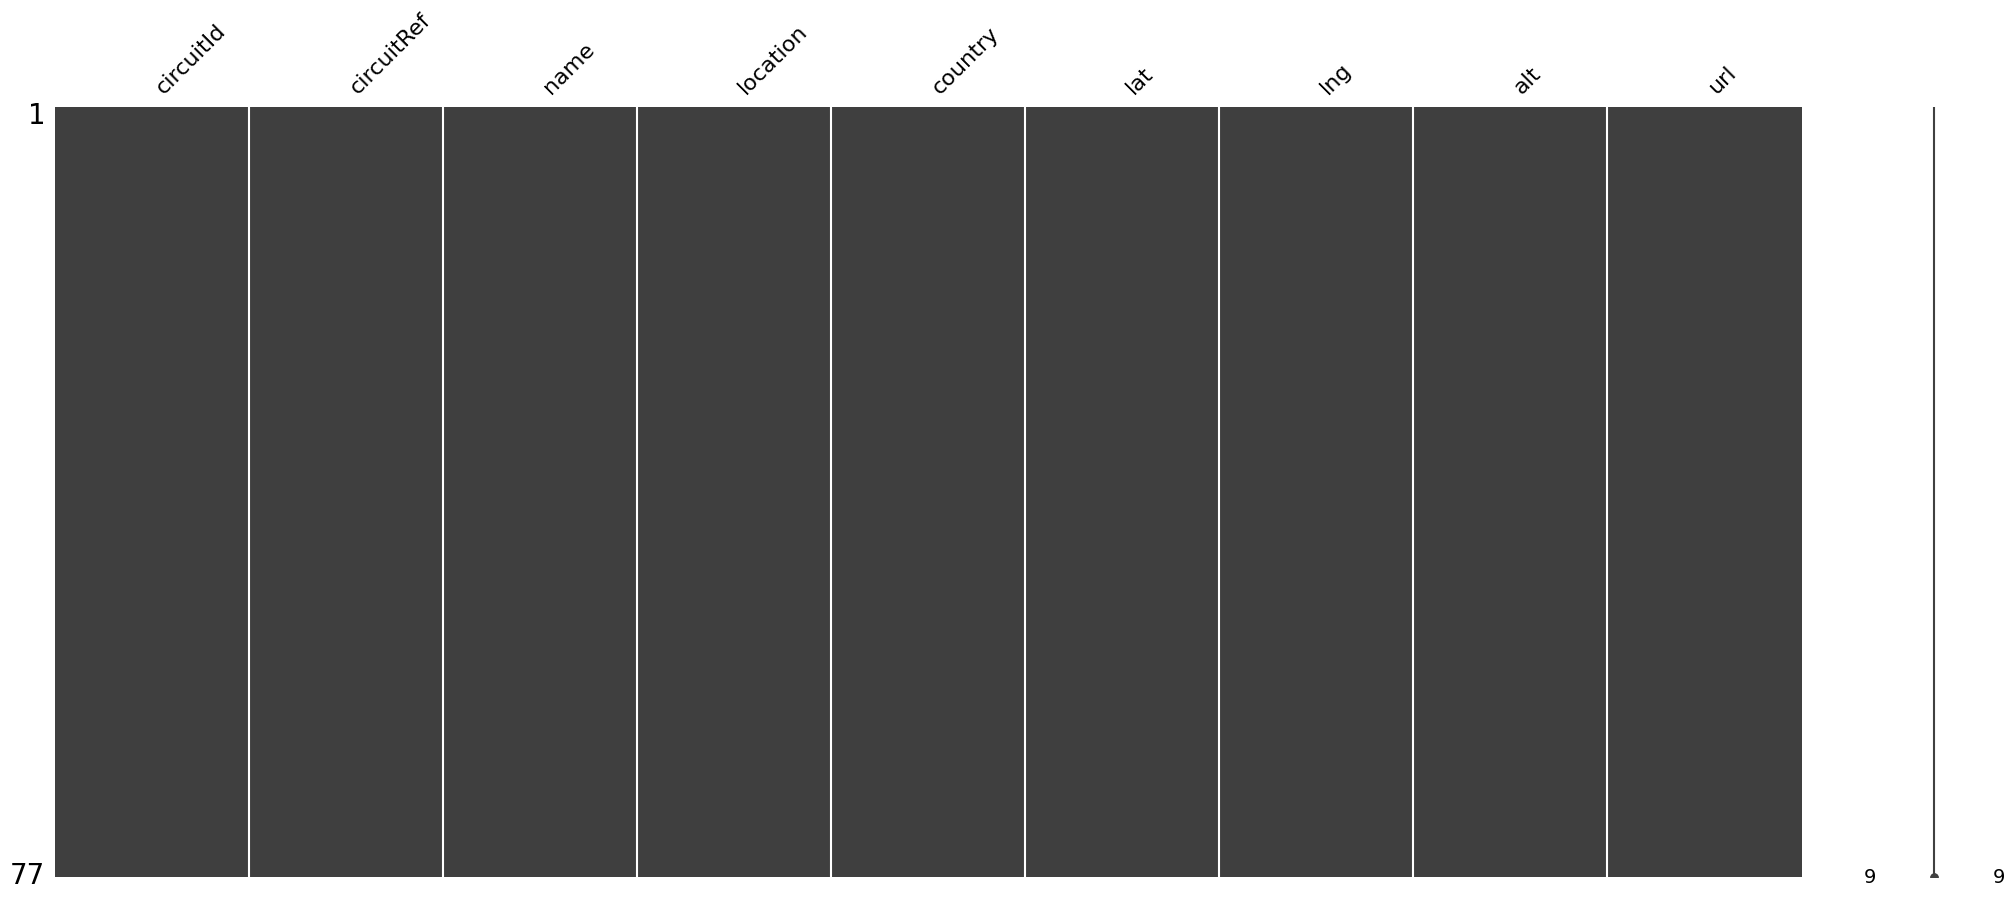

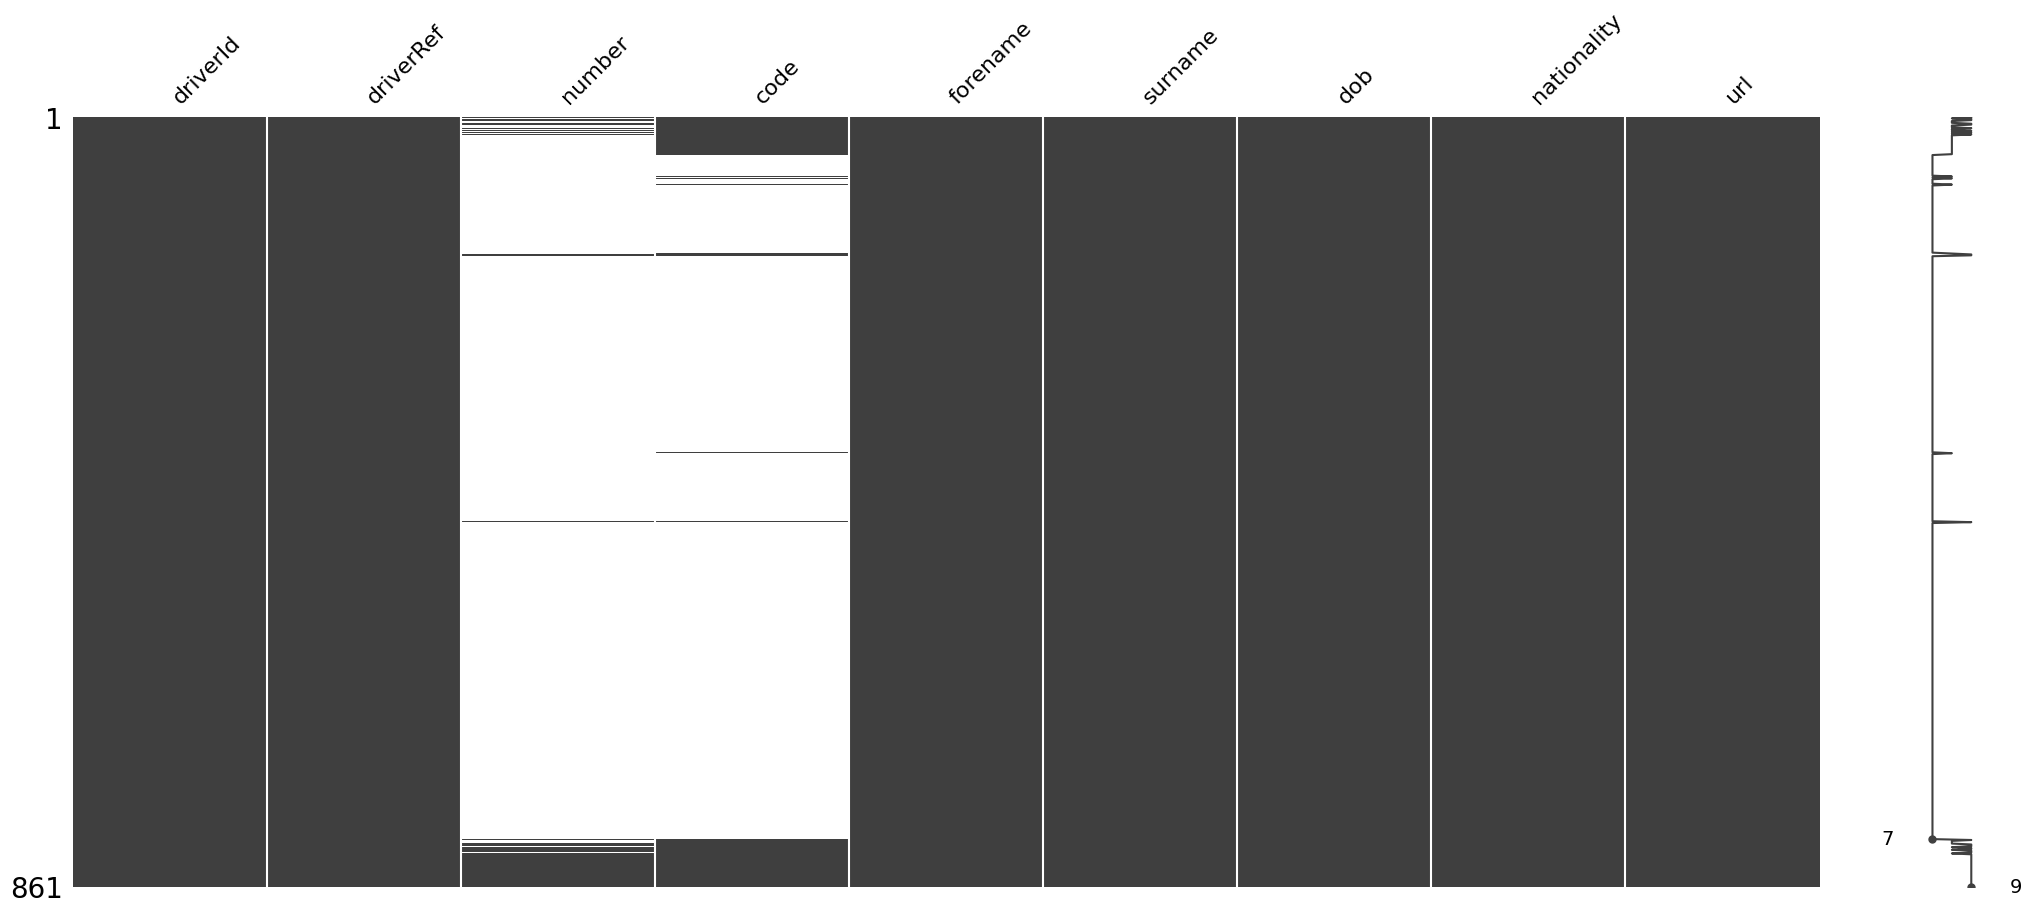

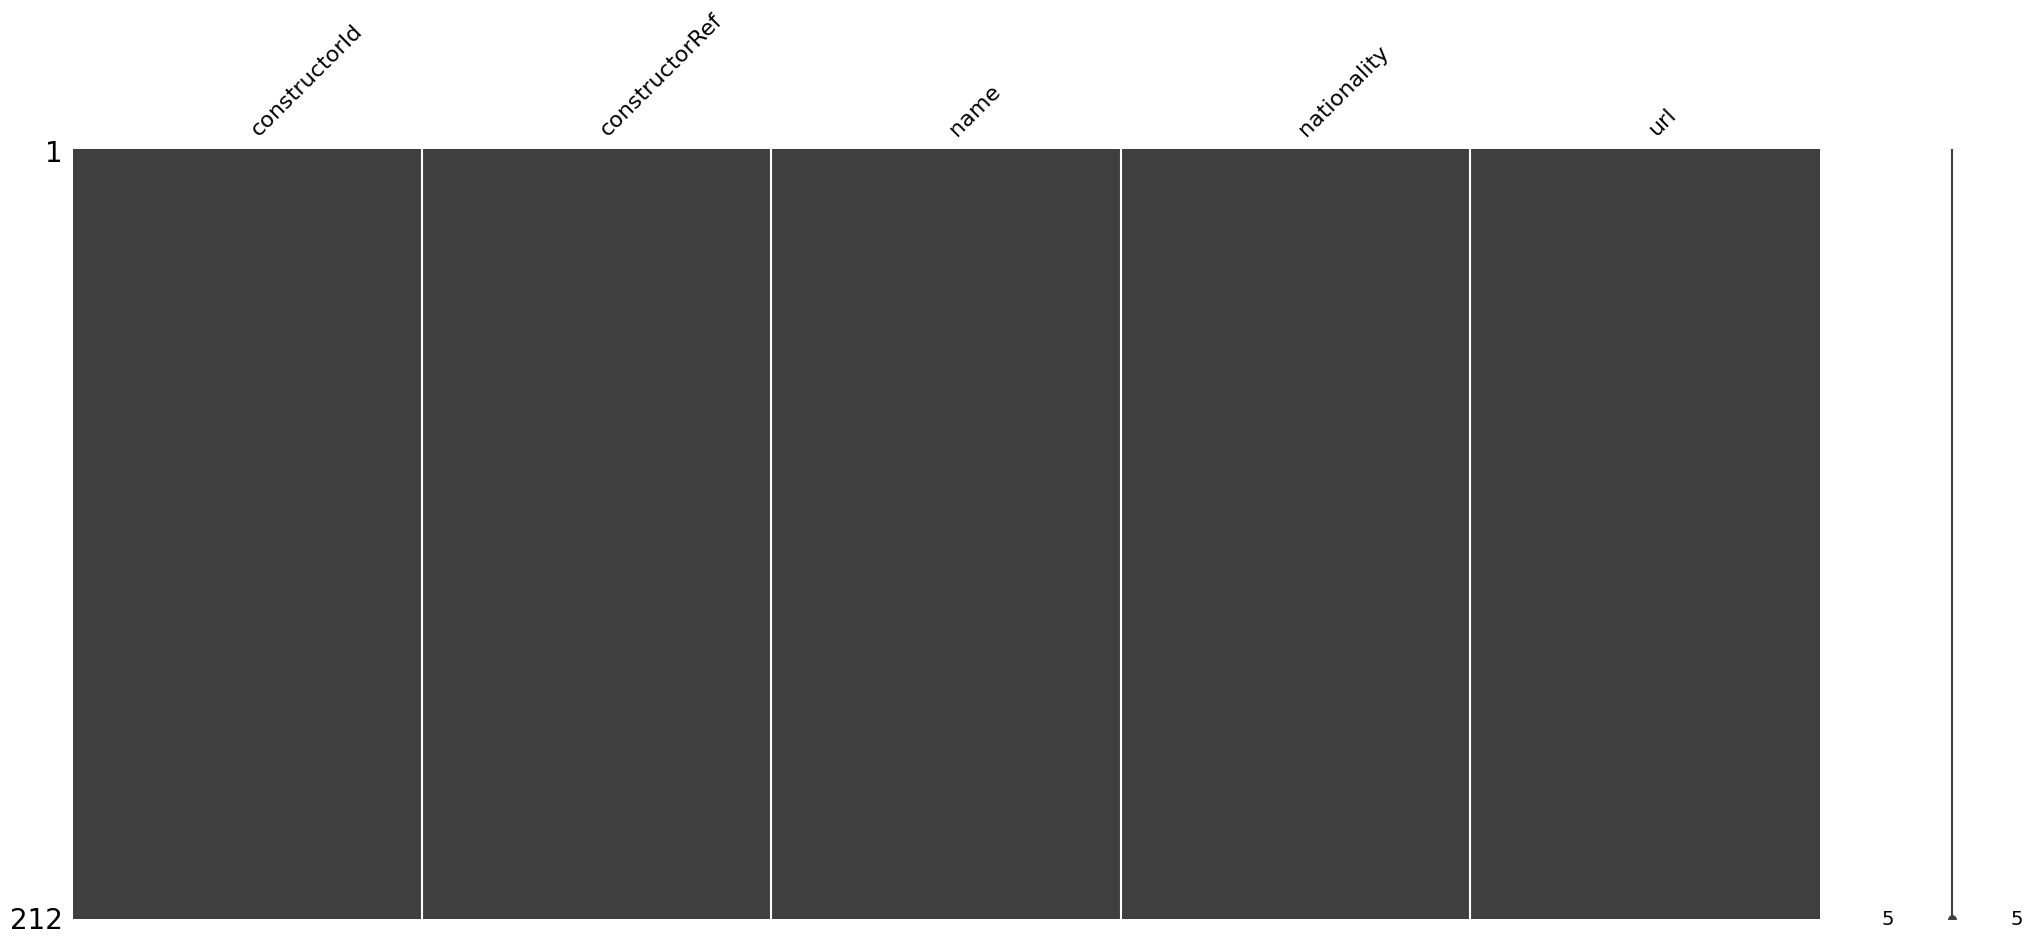

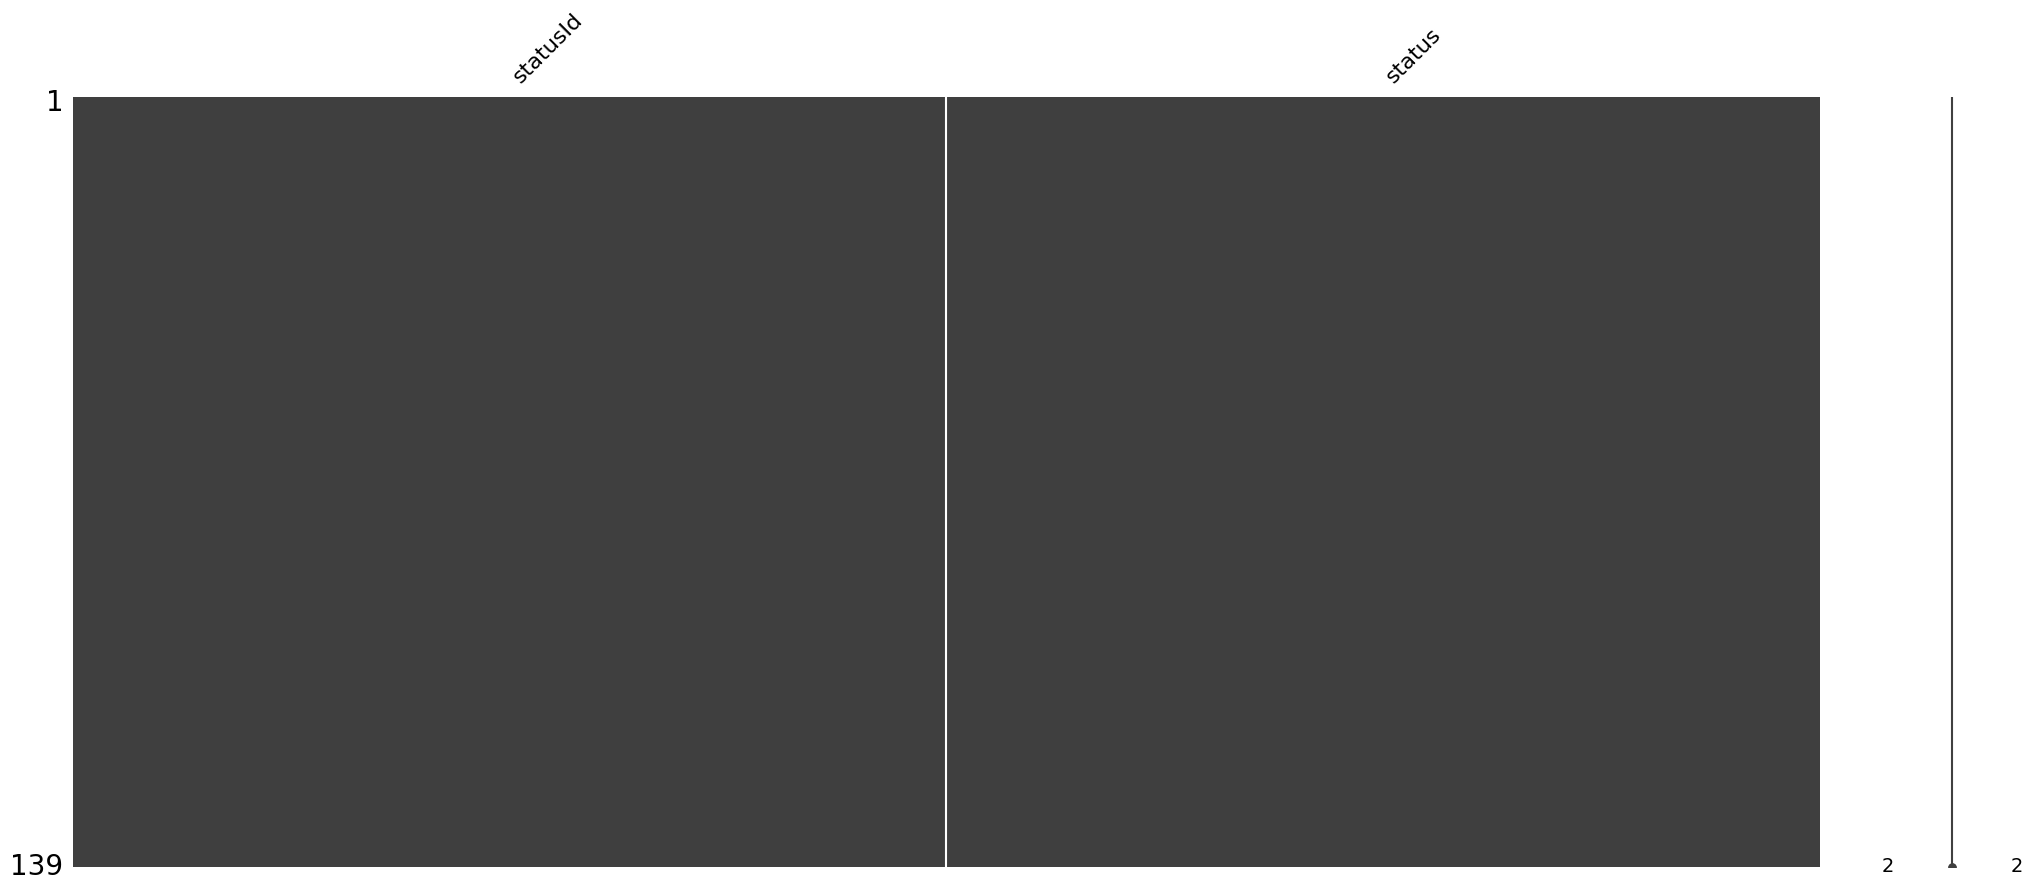

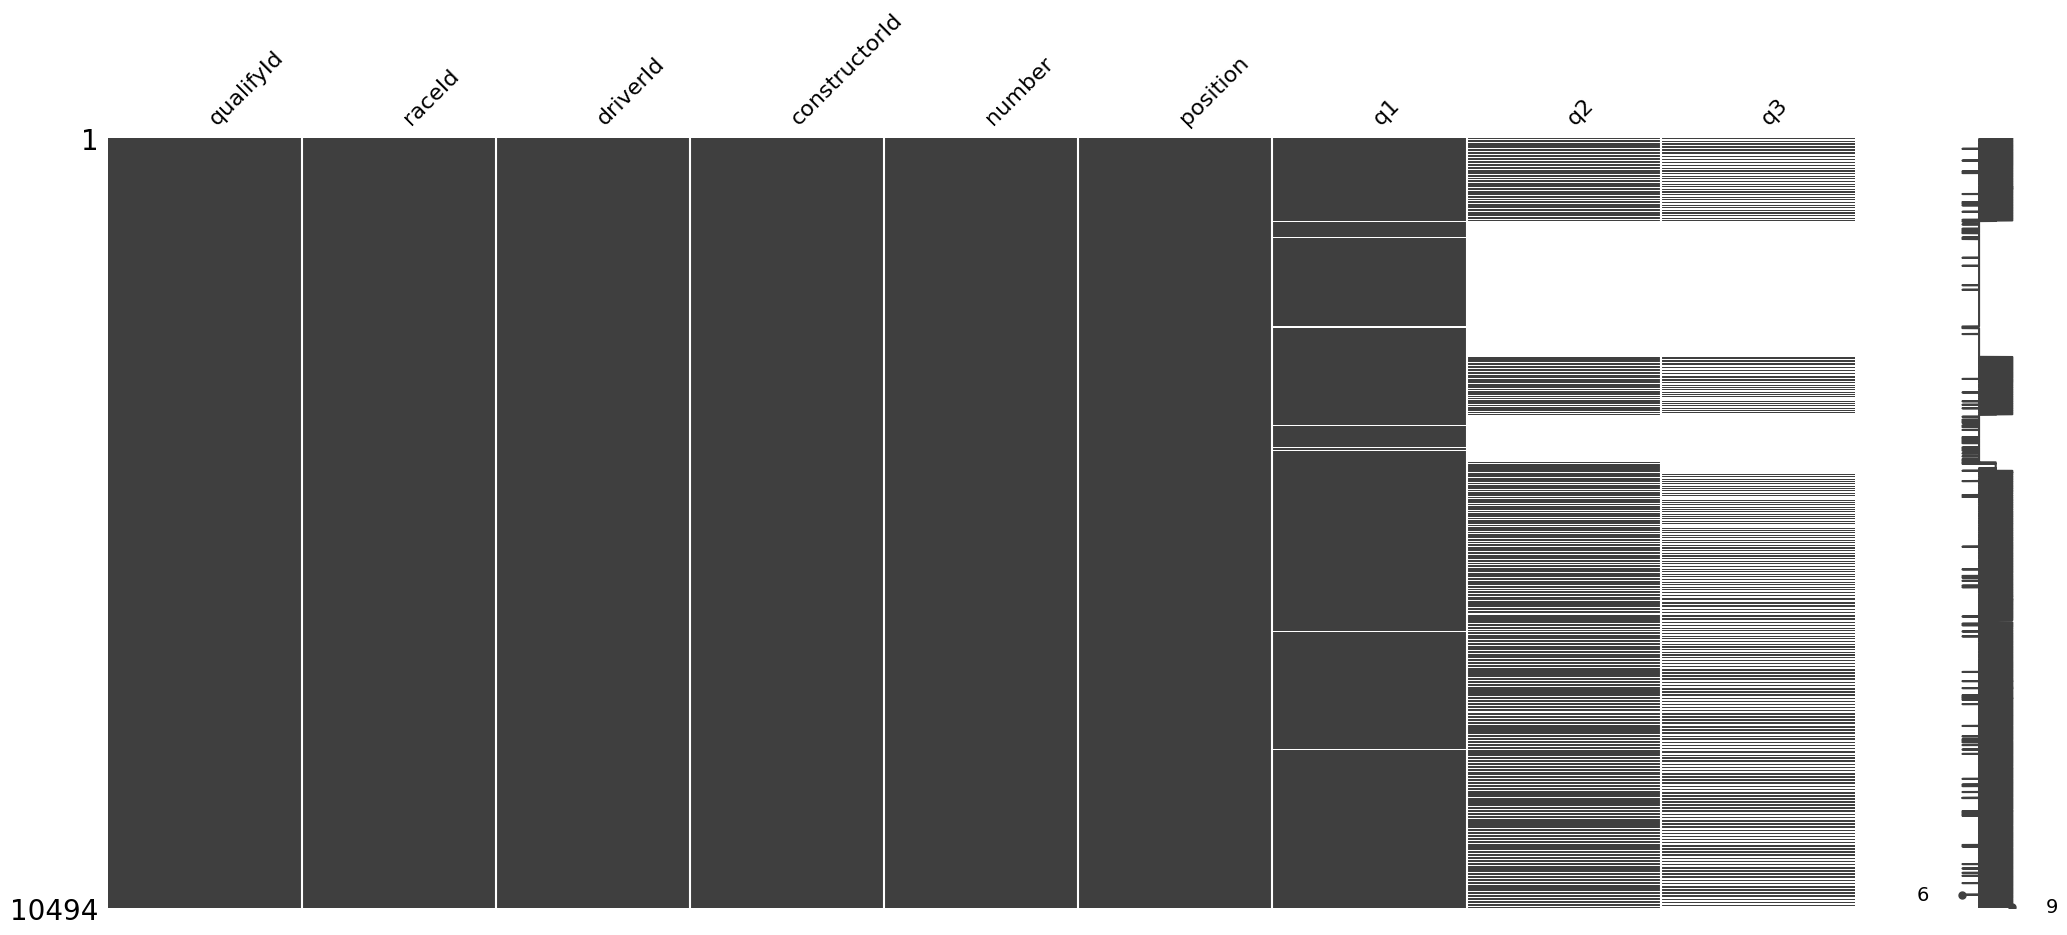

In [27]:
# Visualizing missing entries in the tables
msno.matrix(races)
msno.matrix(results)
msno.matrix(circuits)
msno.matrix(drivers)
msno.matrix(constructors)
msno.matrix(status)
msno.matrix(qualifying)

In [28]:
qualifying.head()

,qualifyId,raceId,driverId,constructorId,number,position,q1,q2,q3
0,1,18,1,1,22,1,1:26.572,1:25.187,1:26.714
1,2,18,9,2,4,2,1:26.103,1:25.315,1:26.869
2,3,18,5,1,23,3,1:25.664,1:25.452,1:27.079
3,4,18,13,6,2,4,1:25.994,1:25.691,1:27.178
4,5,18,2,2,3,5,1:25.960,1:25.518,1:27.236


In [29]:
races = races.drop(columns=['time', 'fp1_date', 'fp1_time', 'fp2_date', 'fp2_time', 'fp3_date', 'fp3_time', 'quali_date', 'quali_time', 'sprint_date', 'sprint_time'])
results = results.drop(columns=['position', 'time', 'milliseconds', 'fastestLap', 'rank', 'fastestLapTime', 'fastestLapSpeed'])
drivers = drivers.drop(columns=['number', 'code'])
qualifying = qualifying.drop(columns=['q2', 'q3'])

qualifying = qualifying.dropna(subset=["q1"])

<Axes: >

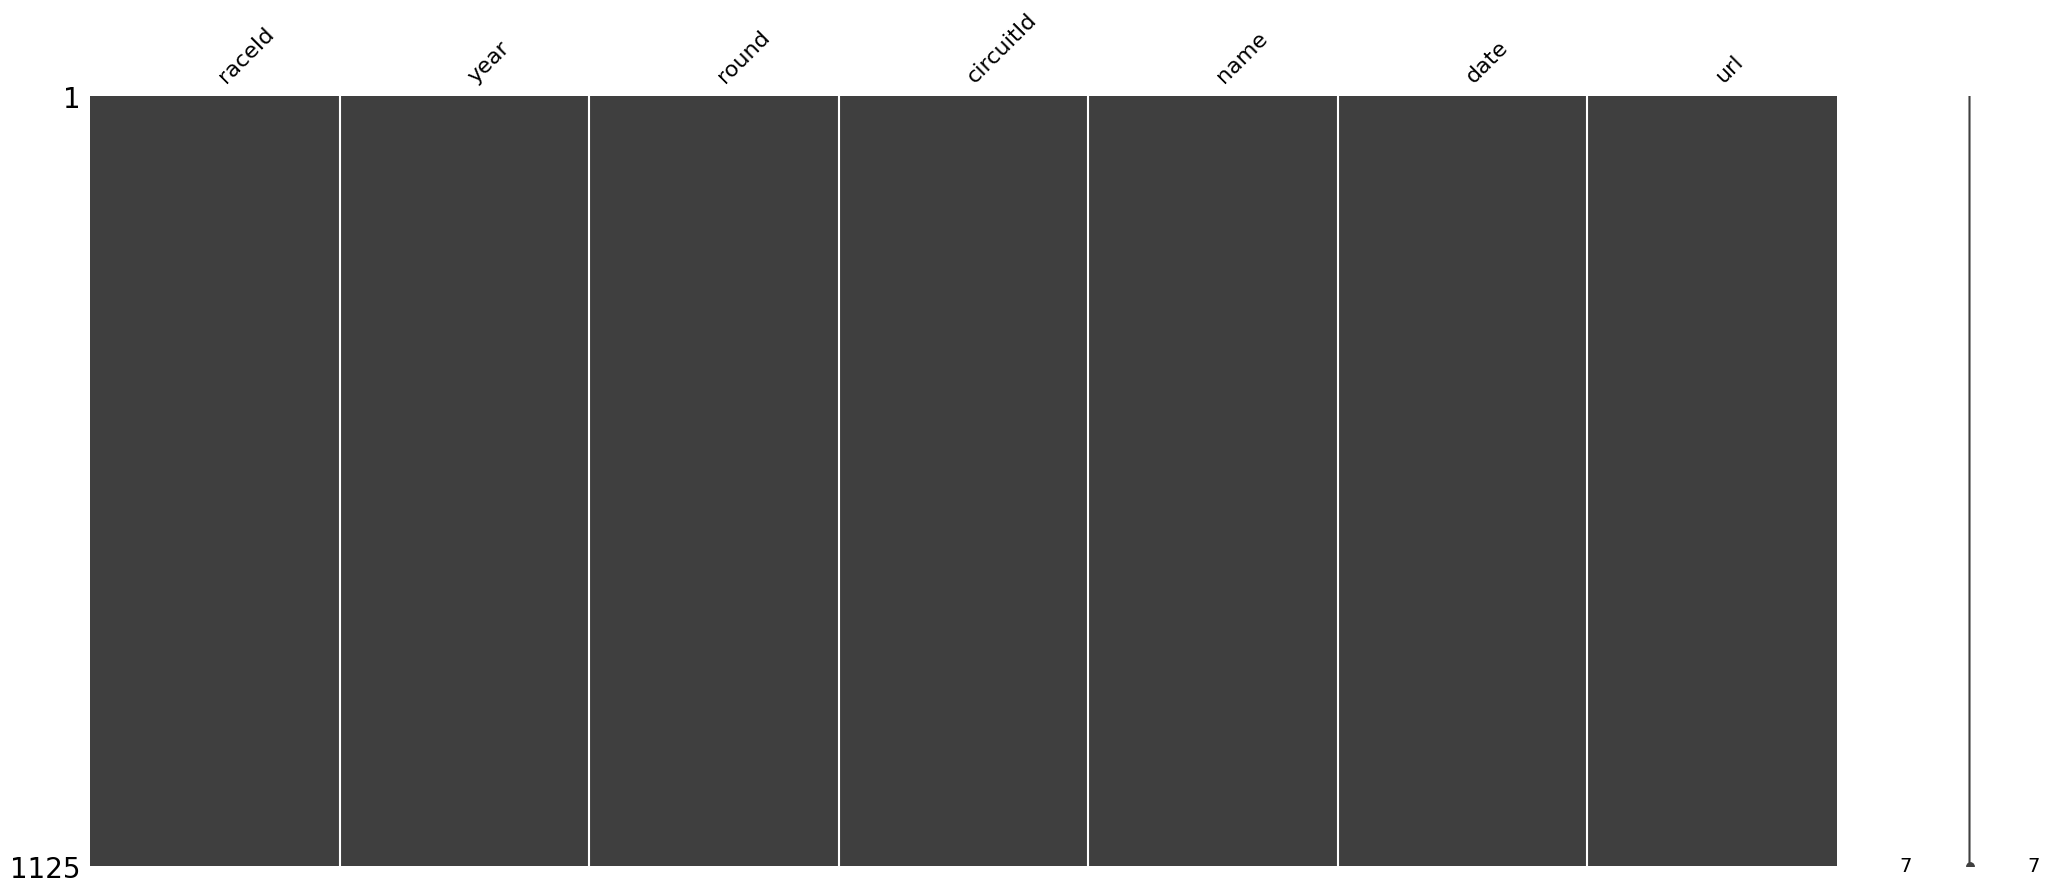

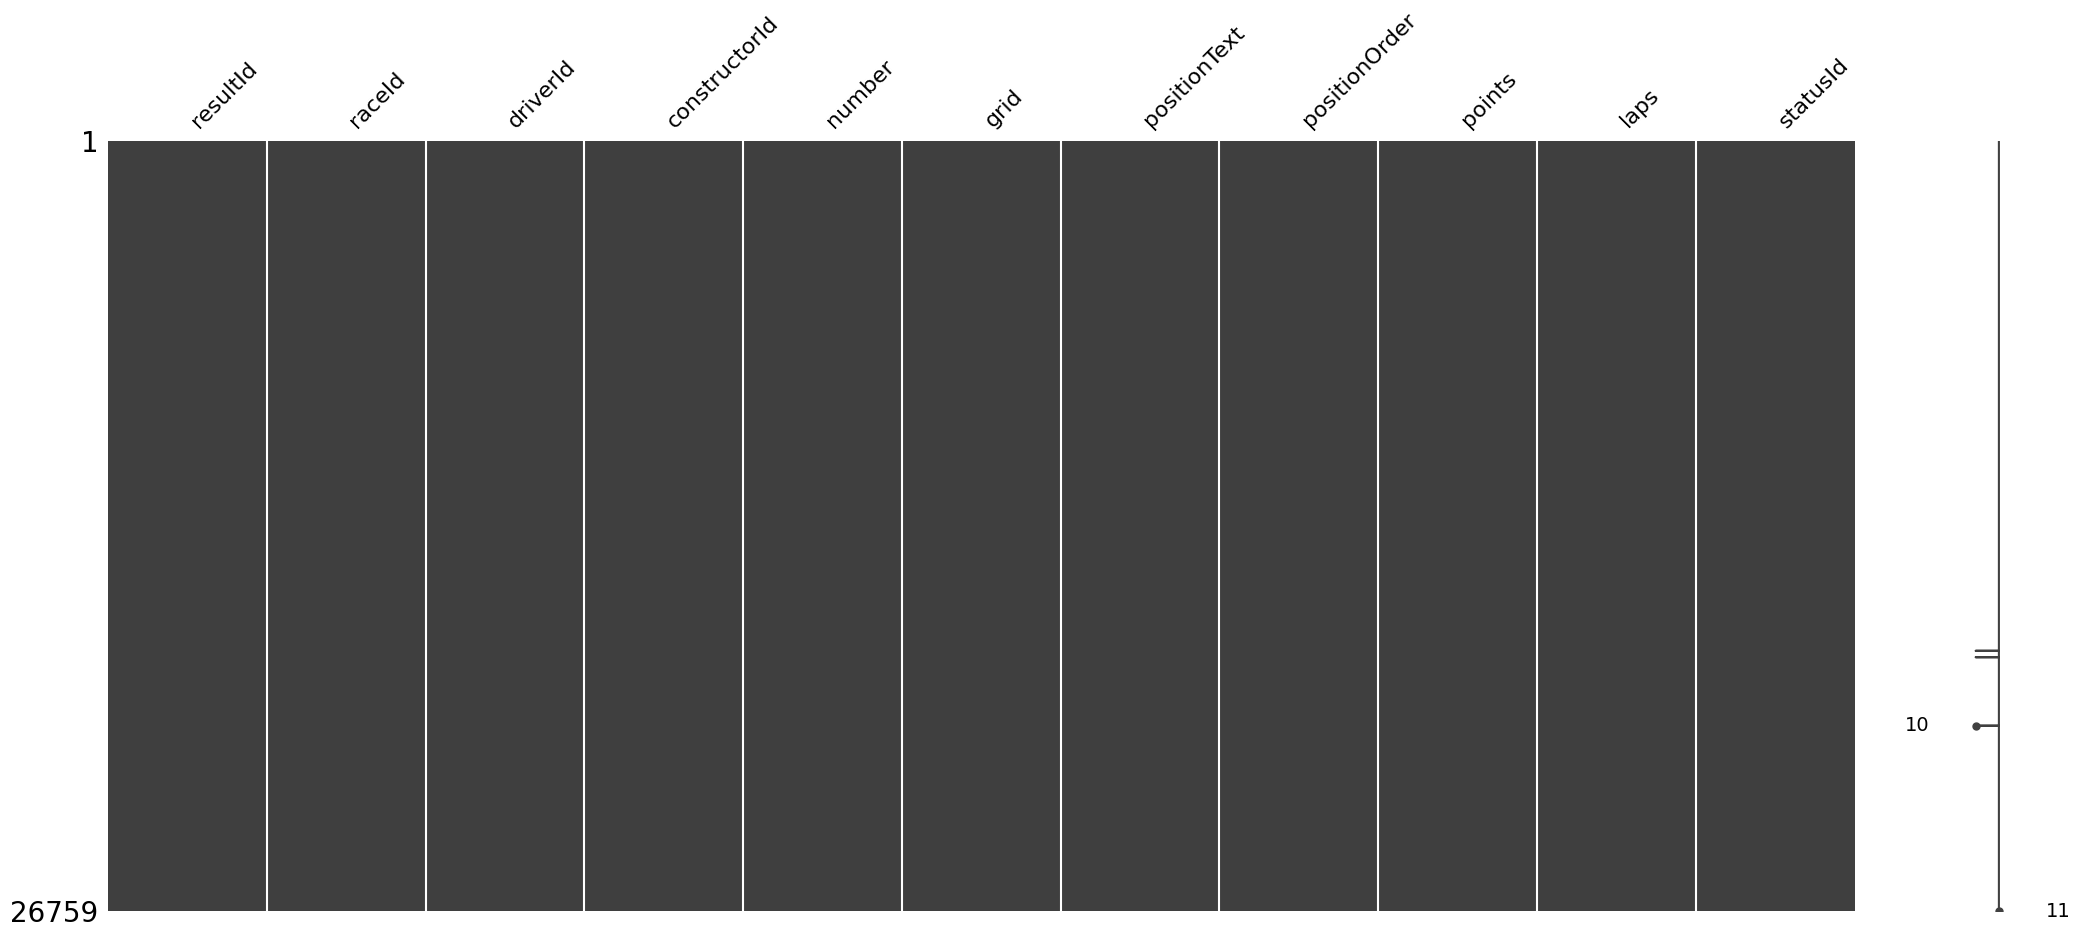

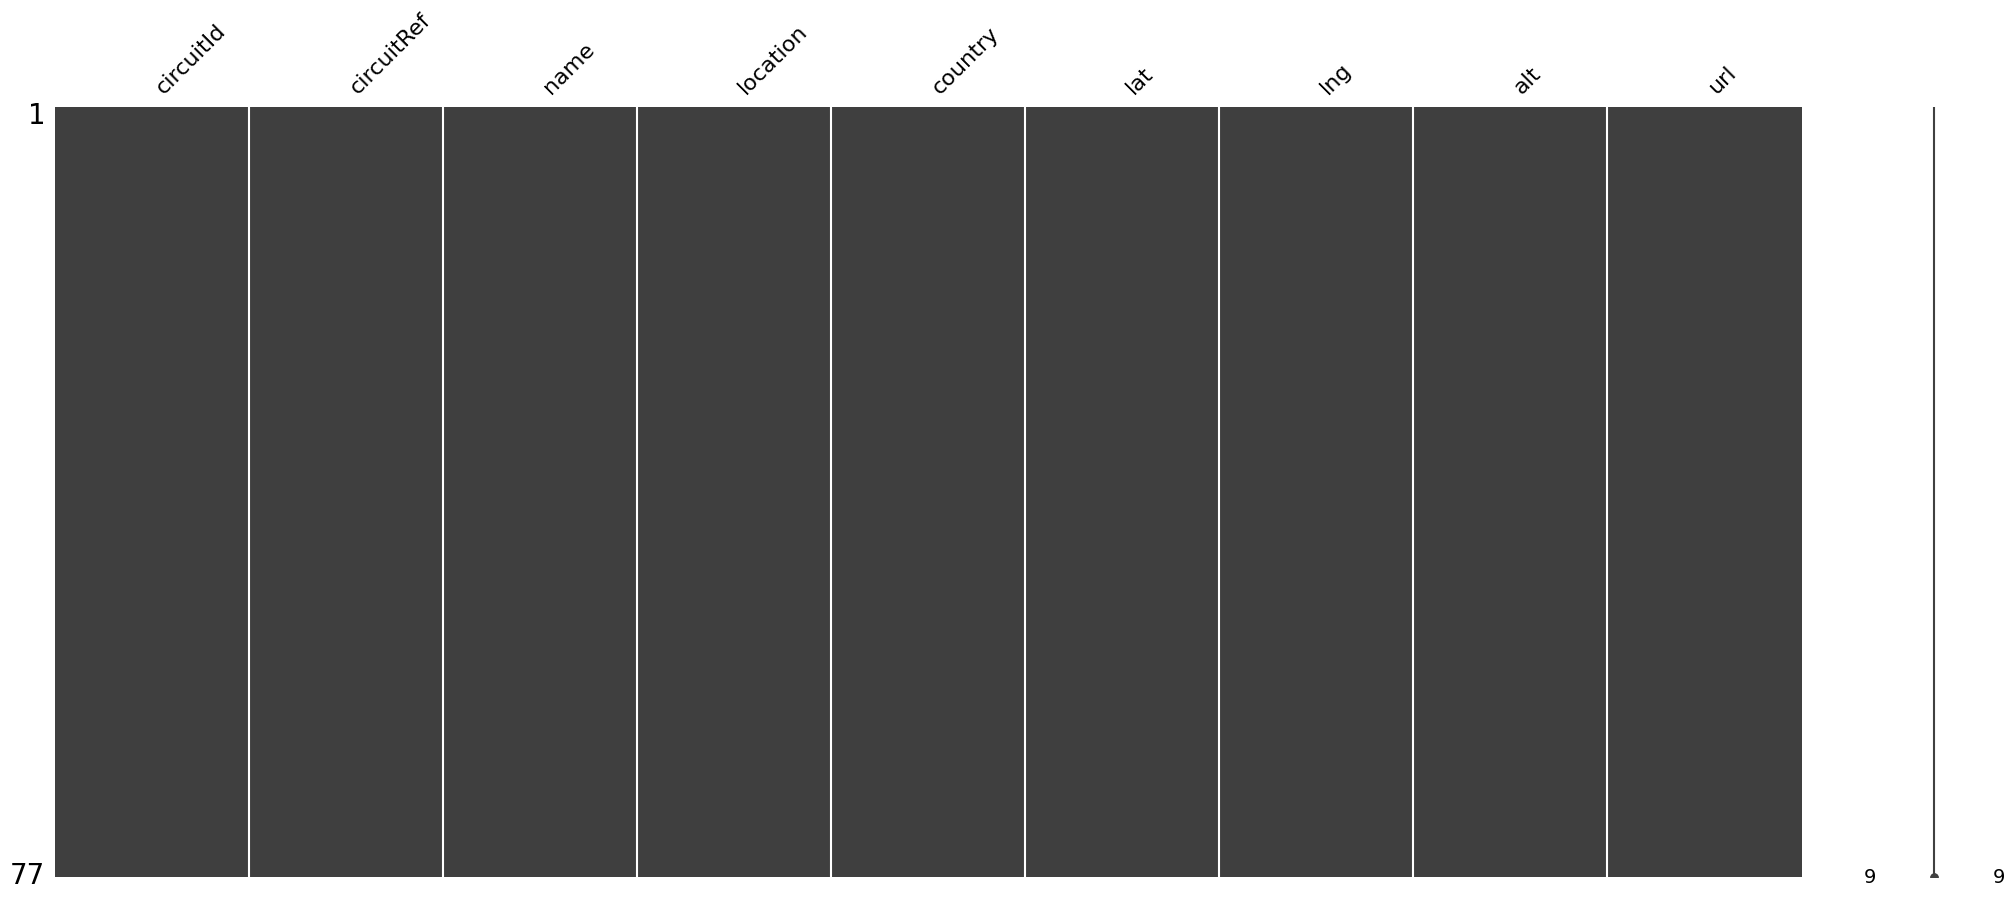

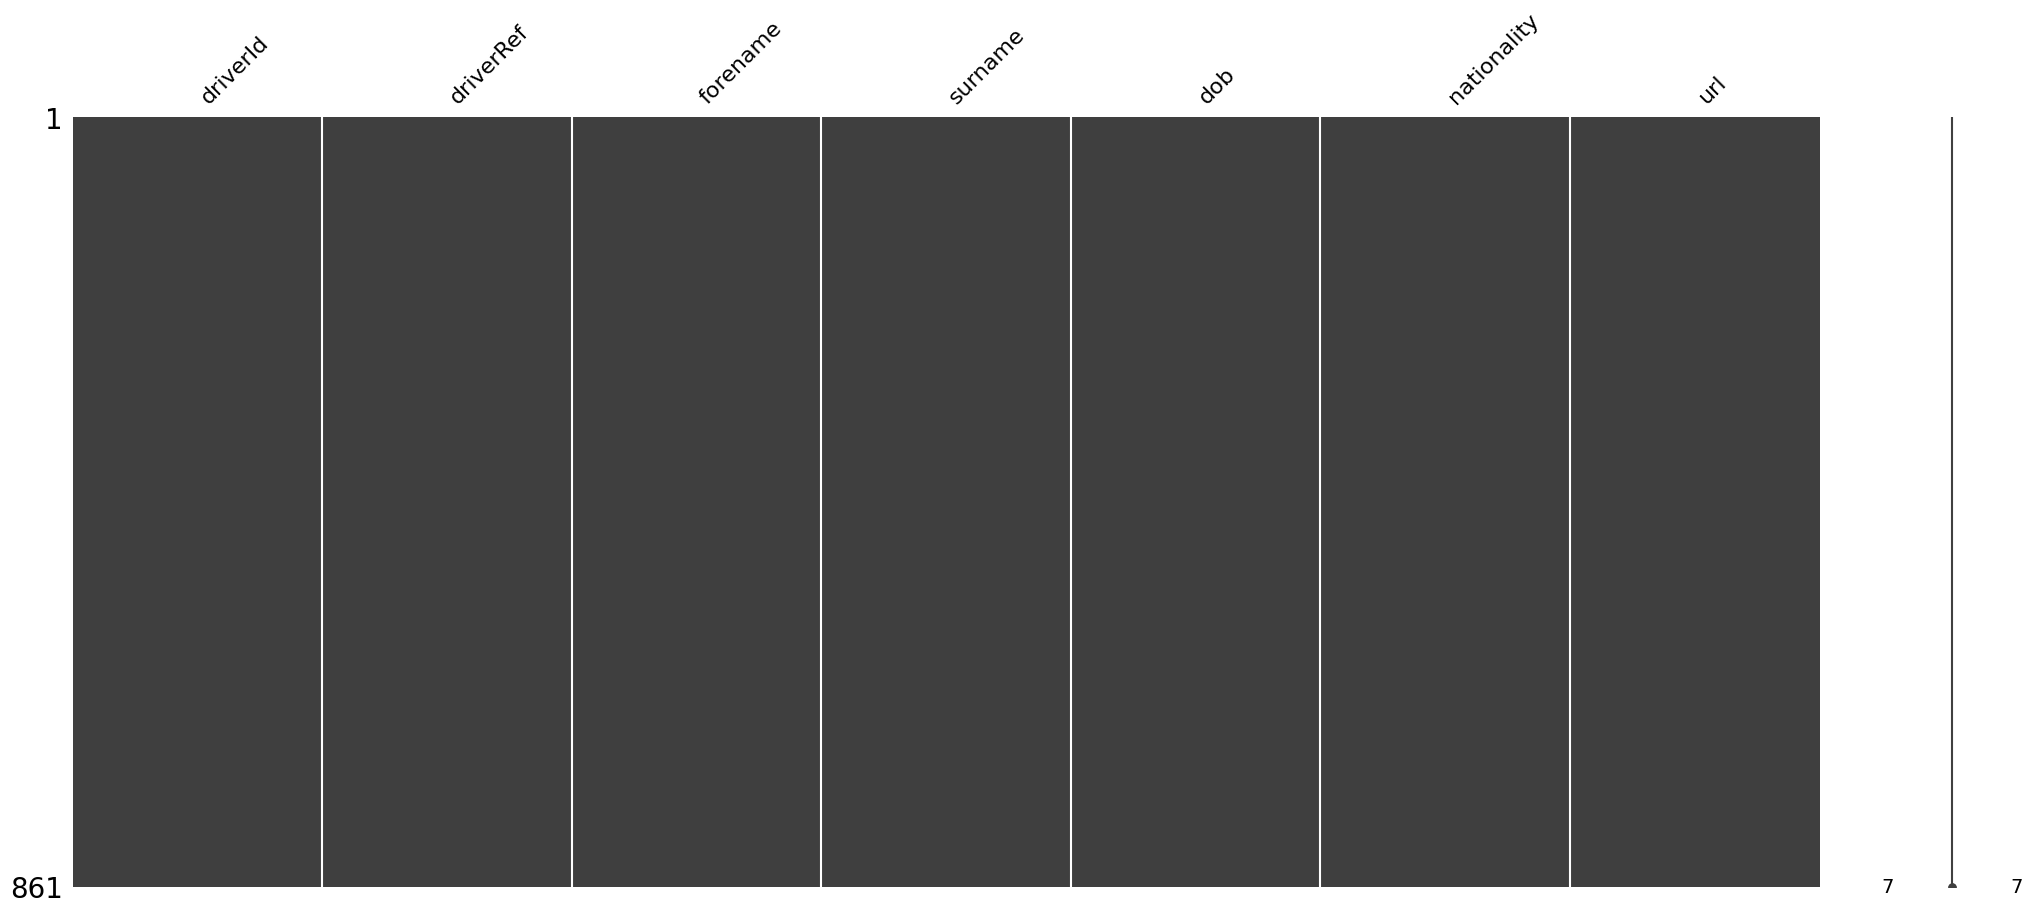

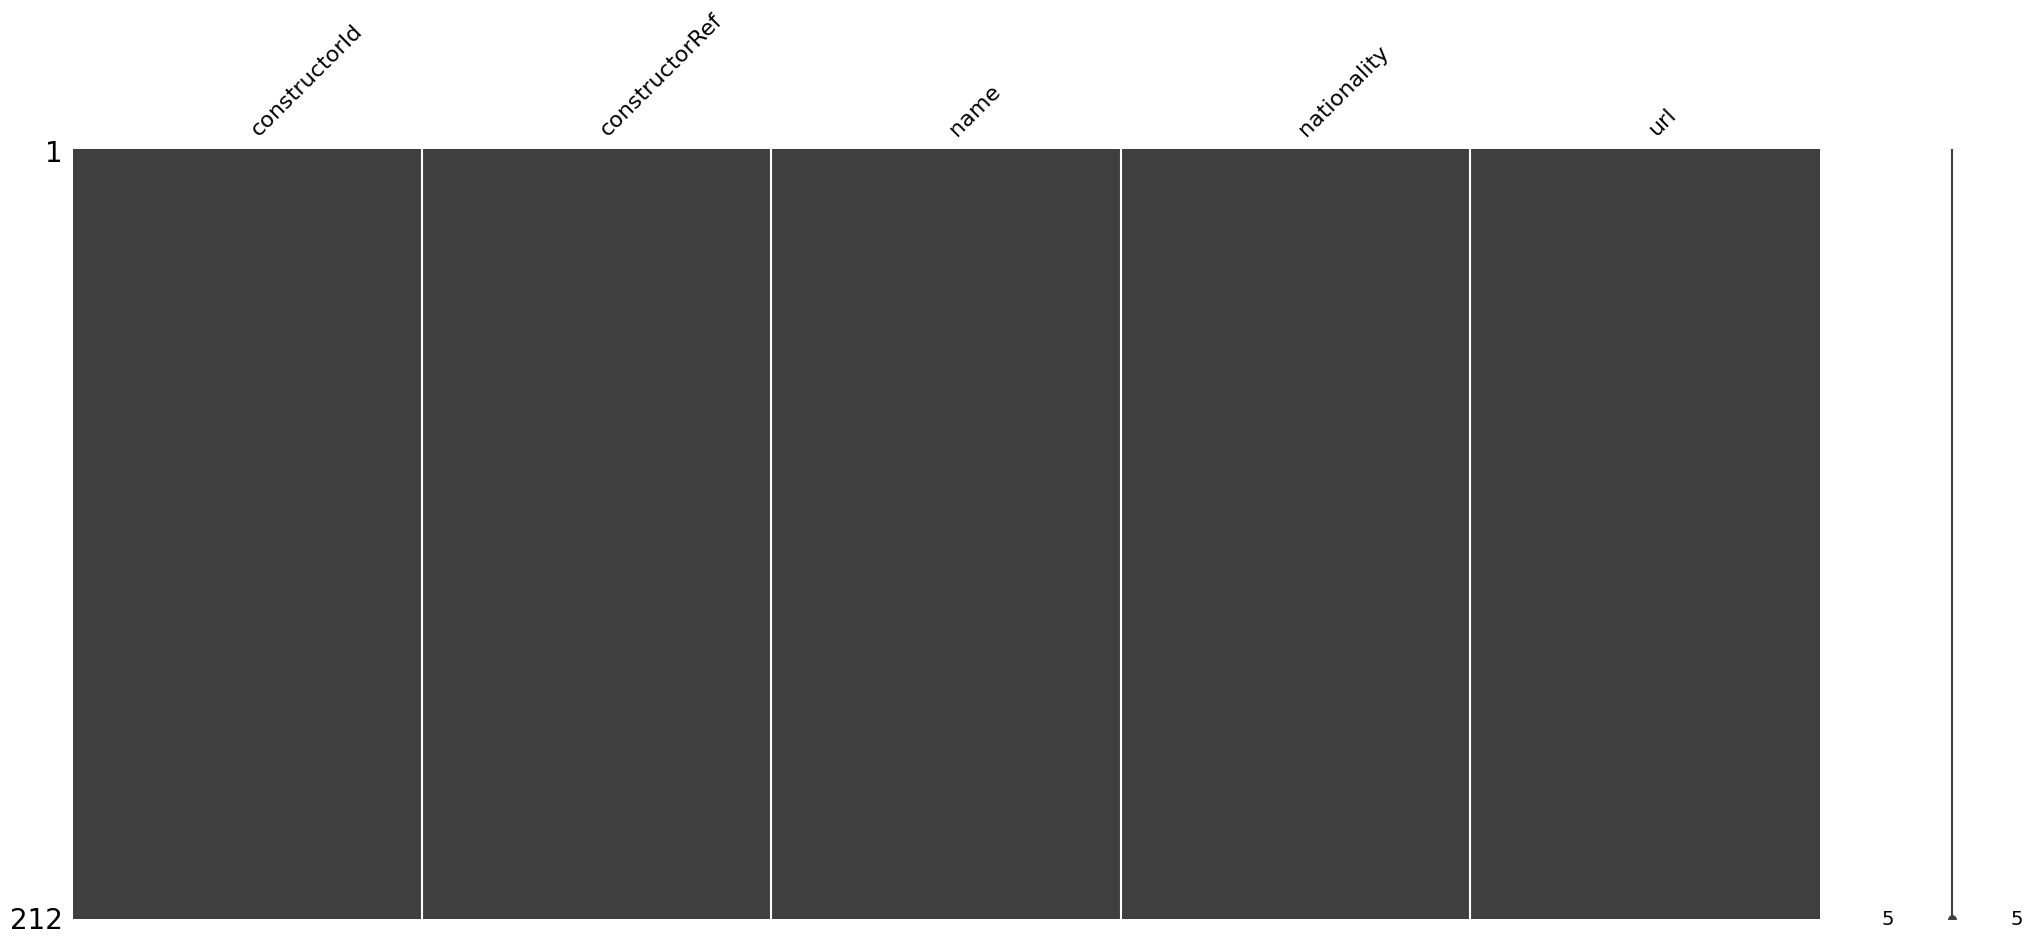

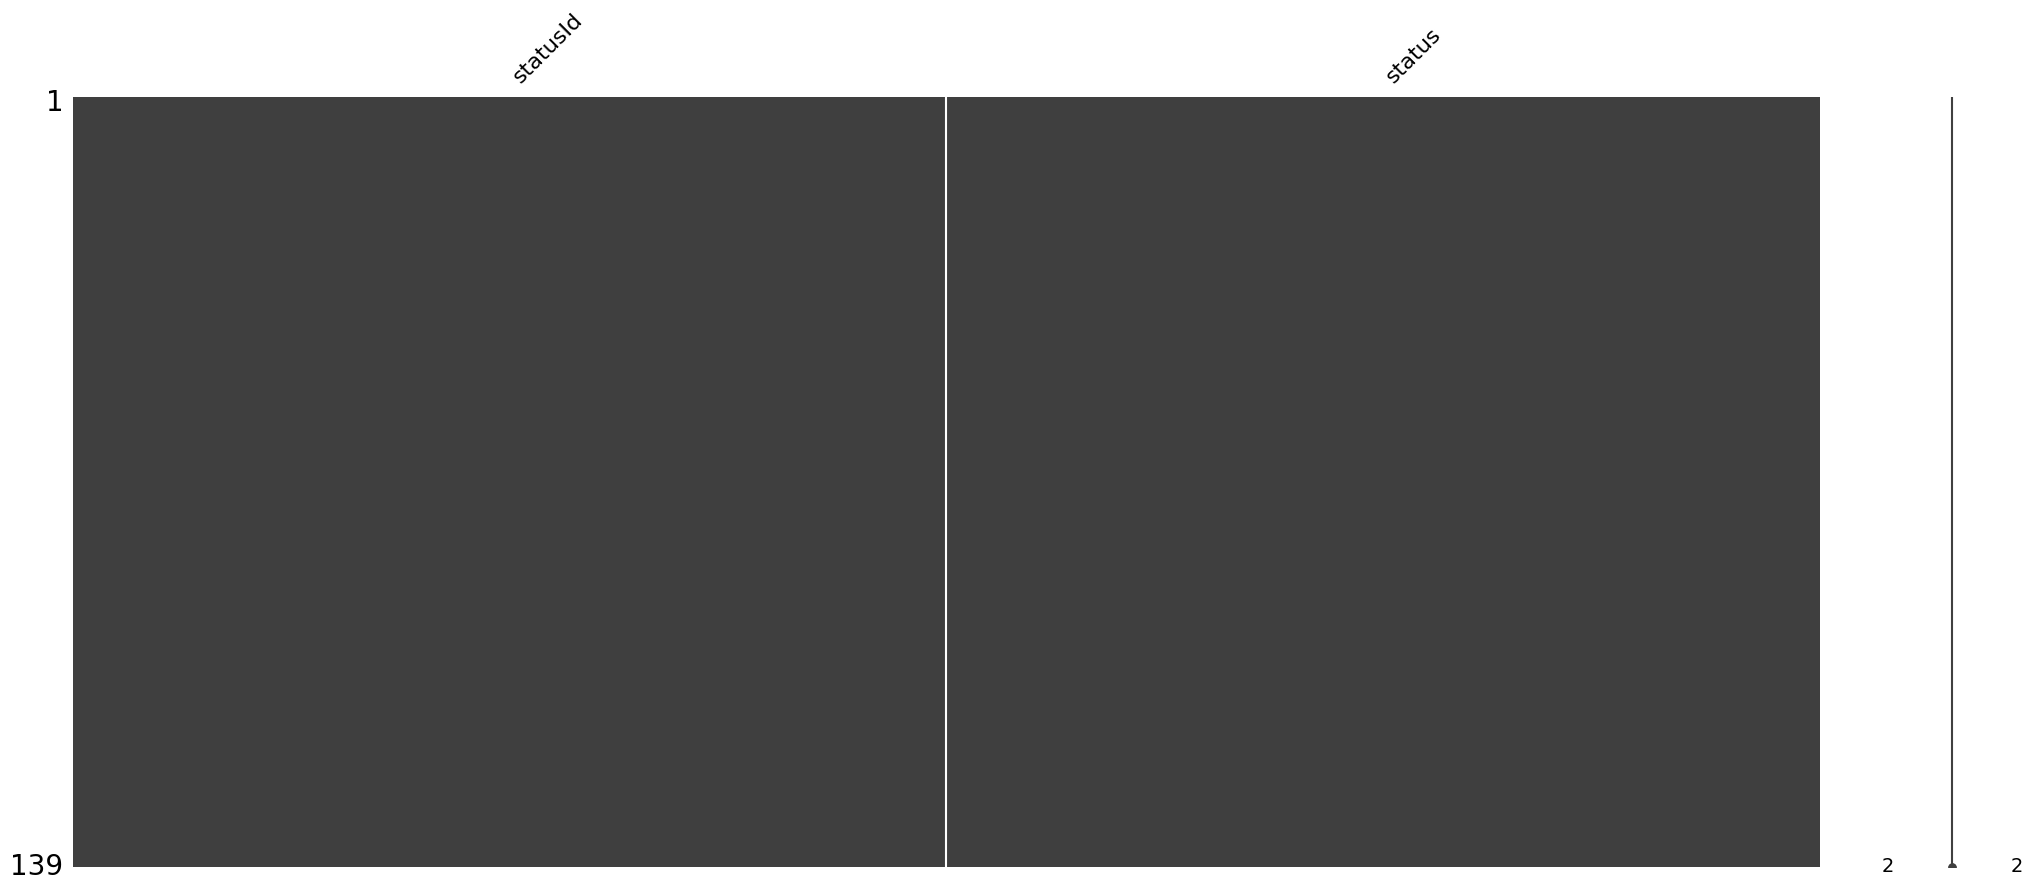

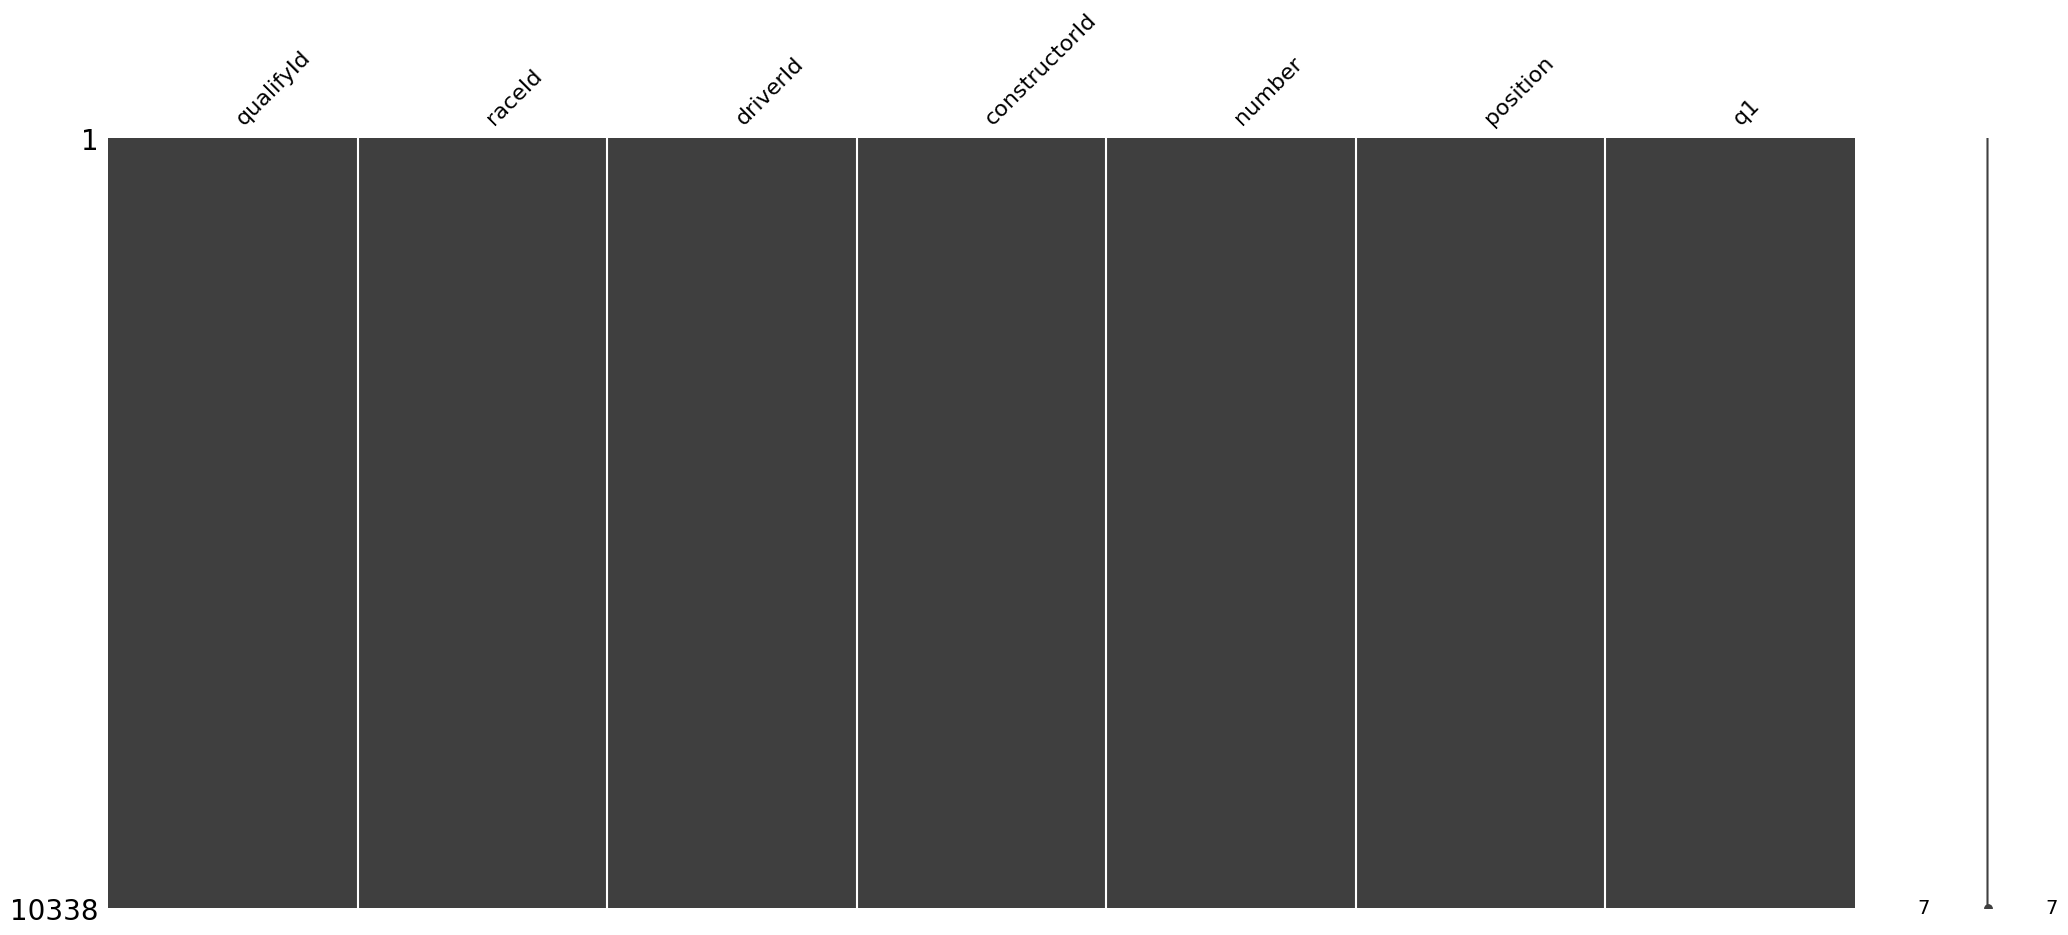

In [30]:
# Visualizing table entries after data cleaning
msno.matrix(races)
msno.matrix(results)
msno.matrix(circuits)
msno.matrix(drivers)
msno.matrix(constructors)
msno.matrix(status)
msno.matrix(qualifying)

In [31]:
races["date"] = pd.to_datetime(races["date"])
qualifying["q1"] = pd.to_datetime(qualifying["q1"], format="%M:%S.%f").dt.time

In [32]:
results = results.drop_duplicates(subset=['raceId', 'driverId'], keep='first')

In [33]:
df = results.merge(races[['raceId', 'circuitId']], on='raceId', validate='many_to_one')
df = df.merge(circuits[['circuitId', 'country']], on='circuitId', validate='many_to_one')
df = df.merge(drivers[['driverId', 'nationality']], on='driverId', validate='many_to_one')

df['podium'] = (df['positionOrder'] <= 3).astype(int)

df.head()

,resultId,raceId,driverId,constructorId,number,grid,positionText,positionOrder,points,laps,statusId,circuitId,country,nationality,podium
0,1,18,1,1,22,1,1,1,10.0,58,1,1,Australia,British,1
1,2,18,2,2,3,5,2,2,8.0,58,1,1,Australia,German,1
2,3,18,3,3,7,7,3,3,6.0,58,1,1,Australia,German,1
3,4,18,4,4,5,11,4,4,5.0,58,1,1,Australia,Spanish,0
4,5,18,5,1,23,3,5,5,4.0,58,1,1,Australia,Finnish,0


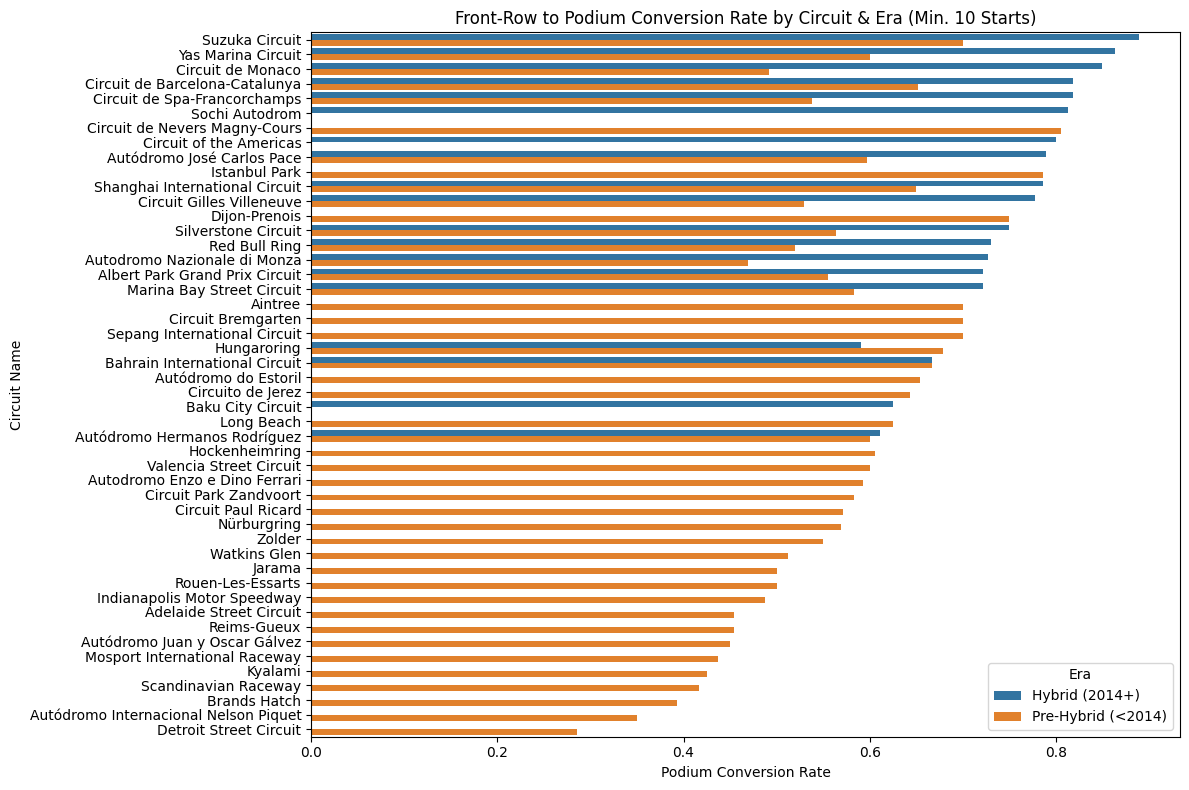

In [34]:
df1 = results.merge(races[['raceId', 'year', 'circuitId']], on='raceId')
df1 = df1.merge(circuits[['circuitId', 'name']], on='circuitId')

df1['hybrid_era'] = df1['year'].apply(lambda x: 'Hybrid (2014+)' if x >= 2014 else 'Pre-Hybrid (<2014)') # new column hybrid era with values: assigns value 'Hybrid 2014' if during or after 2014, and 'Pre-Hybrid' if before 2014
front_row = df1[df1['grid'].isin([1, 2])].copy() #front row (grid position 1&2 ) records

front_row['podium'] = (front_row['positionOrder'] <= 3).astype(int)

conversion = front_row.groupby(['name', 'hybrid_era'])['podium'].agg(['mean', 'count']).reset_index()

conversion = conversion[conversion['count'] >= 10] #only take circuits with more or equal to 10 front row starts
conversion = conversion.sort_values(by='mean', ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(data=conversion, x='mean', y='name', hue='hybrid_era')
plt.title('Front-Row to Podium Conversion Rate by Circuit & Era (Min. 10 Starts)')
plt.xlabel('Podium Conversion Rate')
plt.ylabel('Circuit Name')
plt.legend(title='Era')
plt.tight_layout()
plt.show()

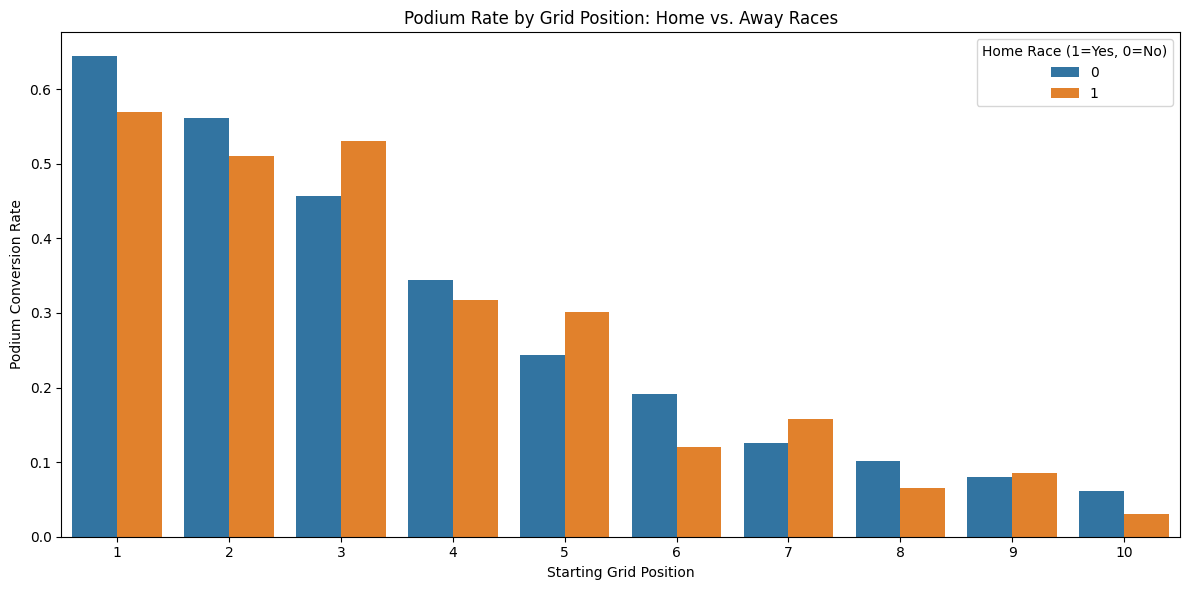

In [56]:
df_2 = results.merge(races[['raceId', 'circuitId']], on='raceId')
df_2 = df_2.merge(circuits[['circuitId', 'country']], on='circuitId')
df_2 = df_2.merge(drivers[['driverId', 'nationality']], on='driverId')


nationality_map = {
    # Mapped to exact country strings found in the dataset
    'Argentine': 'Argentina',
    'Australian': 'Australia',
    'Austrian': 'Austria',
    'Azerbaijani': 'Azerbaijan',
    'Bahraini': 'Bahrain',
    'Belgian': 'Belgium',
    'Brazilian': 'Brazil',
    'Canadian': 'Canada',
    'Chinese': 'China',
    'Dutch': 'Netherlands',
    'French': 'France',
    'German': 'Germany',
    'Hungarian': 'Hungary',
    'Indian': 'India',
    'Italian': 'Italy',
    'Japanese': 'Japan',
    'Korean': 'Korea',          
    'Malaysian': 'Malaysia',
    'Mexican': 'Mexico',
    'Monegasque': 'Monaco',
    'Moroccan': 'Morocco',
    'Portuguese': 'Portugal',
    'Qatari': 'Qatar',
    'Russian': 'Russia',
    'Saudi': 'Saudi Arabia',
    'Singaporean': 'Singapore',
    'South African': 'South Africa',
    'Spanish': 'Spain',
    'Swedish': 'Sweden',
    'Swiss': 'Switzerland',
    'Turkish': 'Turkey',
    'Emirati': 'UAE',
    'British': 'UK',
    'American': 'United States',
    'American': 'USA',
    'Finnish': 'Finland',
    'Danish': 'Denmark',
    'New Zealander': 'New Zealand',
    'Colombian': 'Colombia',
    'Polish': 'Poland',
    'Venezuelan': 'Venezuela',
    'Thai': 'Thailand',
    'Indonesian': 'Indonesia',
    'Irish': 'Ireland',
    'Czech': 'Czechia',
    'Chilean': 'Chile',
    'Uruguayan': 'Uruguay',
    'Rhodesian': 'Zimbabwe'
}

df_2['driver_country'] = df_2['nationality'].map(nationality_map).fillna(df_2['nationality'])

df_2['is_home'] = (df_2['country'] == df_2['driver_country']).astype(int)
df_2['podium'] = (df_2['positionOrder'] <= 3).astype(int)

top_10_grid = df_2[df_2['grid'].between(1, 10)].copy()
grid_home = top_10_grid.groupby(['grid', 'is_home'])['podium'].agg(['mean', 'count']).reset_index()

grid_home = grid_home[grid_home['count'] >= 5]

plt.figure(figsize=(12, 6))
sns.barplot(data=grid_home, x='grid', y='mean', hue='is_home')
plt.title('Podium Rate by Grid Position: Home vs. Away Races')
plt.xlabel('Starting Grid Position')
plt.ylabel('Podium Conversion Rate')
plt.legend(title='Home Race (1=Yes, 0=No)')
plt.tight_layout()
plt.show()

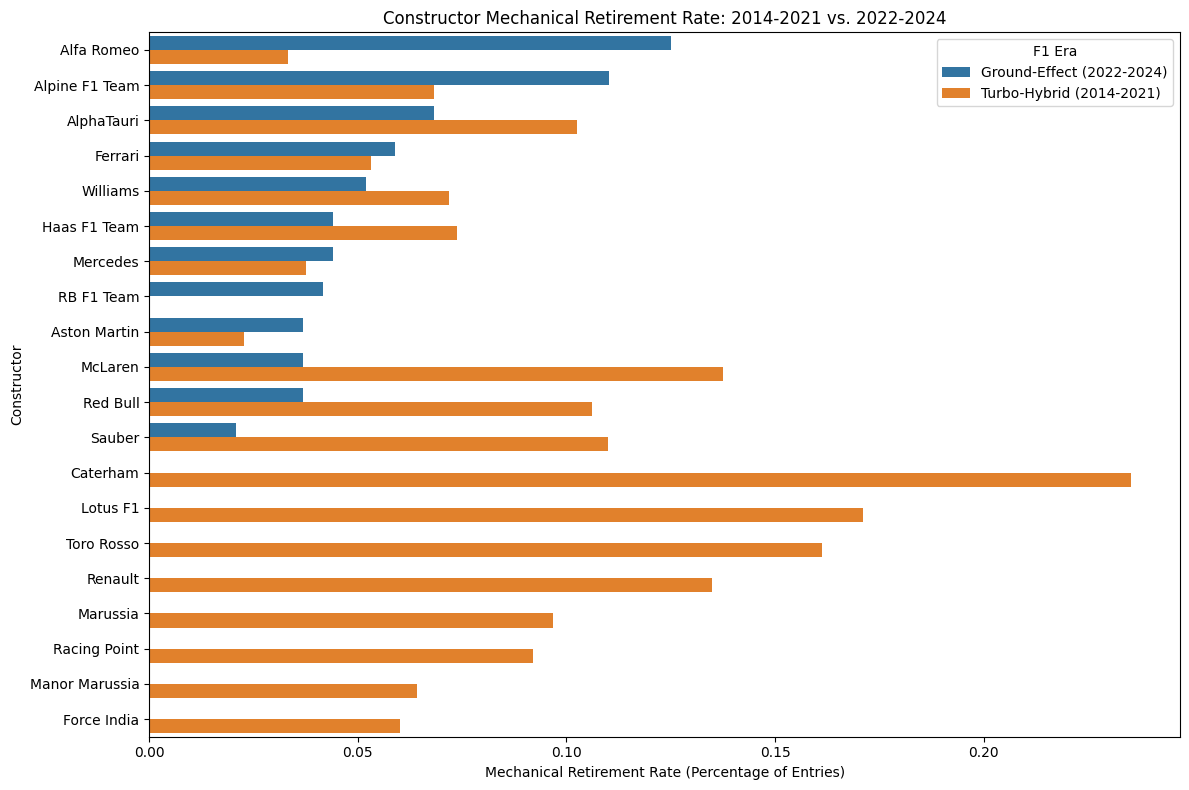

In [58]:
df_3 = results.merge(status, on='statusId')
df_3 = df_3.merge(races[['raceId', 'year']], on='raceId')
df_3 = df_3.merge(constructors[['constructorId', 'name']], on='constructorId')

df_3 = df_3[df_3['year'].between(2014, 2024)].copy()

df_3['era'] = np.where(df_3['year'] <= 2021, 'Turbo-Hybrid (2014-2021)', 'Ground-Effect (2022-2024)')

mechanical_reasons = [
    'Engine', 'Gearbox', 'Transmission', 'Clutch', 'Hydraulics', 'Electrical', 
    'Radiator', 'Suspension', 'Brakes', 'Differential', 'Overheating', 'Mechanical', 
    'Driveshaft', 'Fuel pressure', 'Water pressure', 'Throttle', 'Steering', 
    'Technical', 'Electronics', 'Exhaust', 'Oil leak', 'Water leak', 'Fuel pump', 
    'Track rod', 'Oil pressure', 'Engine fire', 'Engine misfire', 'Pneumatics', 
    'Wheel bearing', 'Fuel system', 'Oil line', 'Power loss', 'Vibrations', 
    'Drivetrain', 'Ignition', 'Chassis', 'Battery', 'Halfshaft', 'Crankshaft', 
    'Alternator', 'Oil pump', 'Fuel leak', 'Injection', 'Distributor', 'Turbo', 
    'CV joint', 'Water pump', 'Spark plugs', 'Fuel pipe', 'Oil pipe', 'Axle', 
    'Water pipe', 'Magneto', 'Supercharger', 'Power Unit', 'ERS', 'Brake duct', 
    'Cooling system'
]

df_3['is_mechanical'] = df_3['status'].isin(mechanical_reasons).astype(int)

mech_rate = df_3.groupby(['name', 'era'])['is_mechanical'].agg(['mean', 'count']).reset_index()

mech_rate = mech_rate[mech_rate['count'] >= 20] #includes constructors with at least 20 starts
mech_rate = mech_rate.sort_values(by=['era', 'mean'], ascending=[True, False])

plt.figure(figsize=(12, 8))
sns.barplot(data=mech_rate, x='mean', y='name', hue='era')
plt.title('Constructor Mechanical Retirement Rate: 2014-2021 vs. 2022-2024')
plt.xlabel('Mechanical Retirement Rate (Percentage of Entries)')
plt.ylabel('Constructor')
plt.legend(title='F1 Era')
plt.tight_layout()
plt.show()